# IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print(" All libraries imported successfully!")

 All libraries imported successfully!


# LOAD DATASET

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
print(f"\n--- Dataset Shape: {df.shape} ---")
print(df.head())


--- Dataset Shape: (7043, 21) ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV S

In [ ]:
print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Basic Statistics ---")
print(df.describe())


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

# DATA PREPROCESSING

In [ ]:
# 3.1 Drop customerID (not useful for prediction)
df.drop(columns=['customerID'], inplace=True)

# 3.2 Fix TotalCharges column (has spaces, should be numeric)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
# 3.3 Check missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3.4 Fill missing TotalCharges with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


--- Missing Values ---
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
# 3.5 Encode target column: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3.6 Encode binary categorical columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling']
for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# 3.7 One-Hot Encode multi-class categorical columns
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
              'OnlineBackup', 'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

In [ ]:
print("\n--- Shape After Encoding ---")
print(df.shape)

print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum().sum(), "missing values remaining")


--- Shape After Encoding ---
(7043, 31)

--- Missing Values After Cleaning ---
0 missing values remaining


# EXPLORATORY DATA ANALYSIS (EDA)

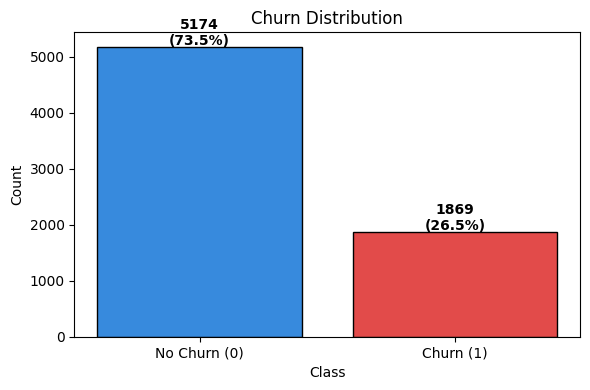


⚠️  Class imbalance ratio → No Churn: 5174 | Churn: 1869


In [ ]:
# Plot 1: Churn Distribution
fig_colors = {'no_churn': '#378ADD', 'churn': '#E24B4A'}

plt.figure(figsize=(6, 4))
counts = df['Churn'].value_counts()
bars = plt.bar(['No Churn (0)', 'Churn (1)'], counts.values,
               color=[fig_colors['no_churn'], fig_colors['churn']], edgecolor='black')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
plt.title('Churn Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot1_churn_distribution.png', dpi=150)
plt.show()
print(f"\n⚠️  Class imbalance ratio → No Churn: {counts[0]} | Churn: {counts[1]}")

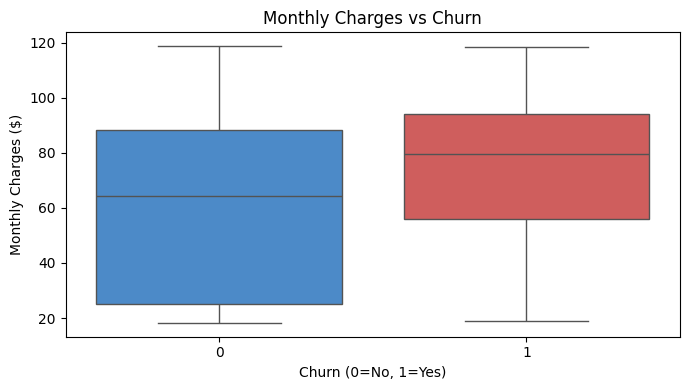

In [ ]:
# Plot 2: Monthly Charges vs Churn (Boxplot)
plt.figure(figsize=(7, 4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            palette={'0': fig_colors['no_churn'], '1': fig_colors['churn']})
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('plot2_monthly_charges_boxplot.png', dpi=150)
plt.show()

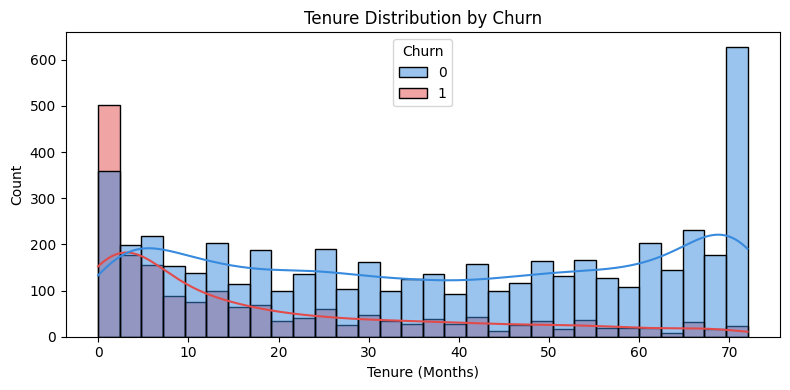

In [ ]:
# Plot 3: Tenure Distribution by Churn
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette={0: fig_colors['no_churn'], 1: fig_colors['churn']}, kde=True)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot3_tenure_distribution.png', dpi=150)
plt.show()

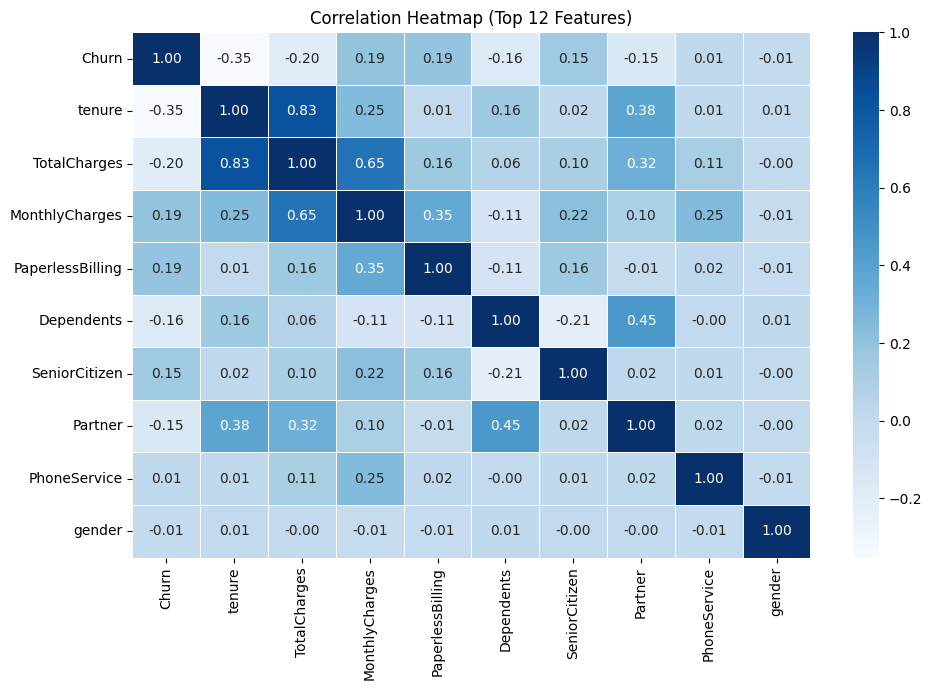

In [ ]:
# Plot 4: Correlation Heatmap (top numeric features)
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
top_features = corr['Churn'].abs().nlargest(12).index
sns.heatmap(numeric_df[top_features].corr(), annot=True, fmt='.2f',
            cmap='Blues', linewidths=0.5)
plt.title('Correlation Heatmap (Top 12 Features)')
plt.tight_layout()
plt.savefig('plot4_correlation_heatmap.png', dpi=150)
plt.show()

# TRAIN-TEST SPLIT

In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n--- Train-Test Split ---")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")


--- Train-Test Split ---
Training samples : 5634
Testing samples  : 1409


In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# MODEL TRAINING

# **Logistic Regression**

In [ ]:
print("\n==================================")
print("    LOGISTIC REGRESSION")
print("==================================")

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, lr_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, lr_prob), 4))


    LOGISTIC REGRESSION
Accuracy : 0.807
ROC-AUC  : 0.8416


In [ ]:
print("Logistic Regression — Classification Report:\n")

print(classification_report(
    y_test, lr_pred,
    target_names=['No Churn', 'Churn']
))

Logistic Regression — Classification Report:

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



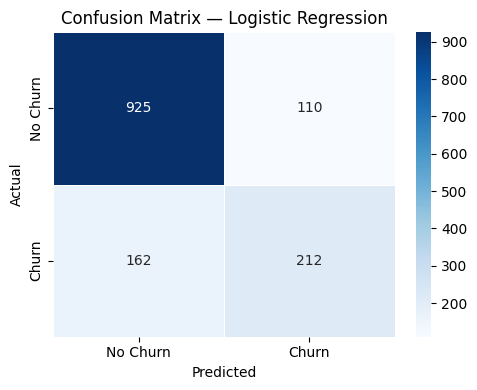

In [ ]:
# Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'], linewidths=0.5)
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

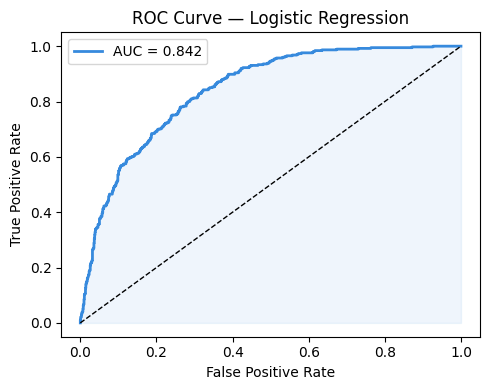

In [ ]:
# ROC Curve
plt.figure(figsize=(5, 4))
fpr, tpr, _ = roc_curve(y_test, lr_prob)
auc = roc_auc_score(y_test, lr_prob)
plt.plot(fpr, tpr, color='#378ADD', lw=2, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.fill_between(fpr, tpr, alpha=0.08, color='#378ADD')
plt.title('ROC Curve — Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# **RANDOM FOREST**

In [ ]:
print("\n======================")
print("   RANDOM FOREST ")
print("======================")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, rf_prob), 4))


   RANDOM FOREST 
Accuracy : 0.7871
ROC-AUC  : 0.8215


In [ ]:
# Classification Report
print("Random Forest — Classification Report:\n")

print(classification_report(
    y_test, rf_pred,
    target_names=['No Churn', 'Churn']
))

Random Forest — Classification Report:

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



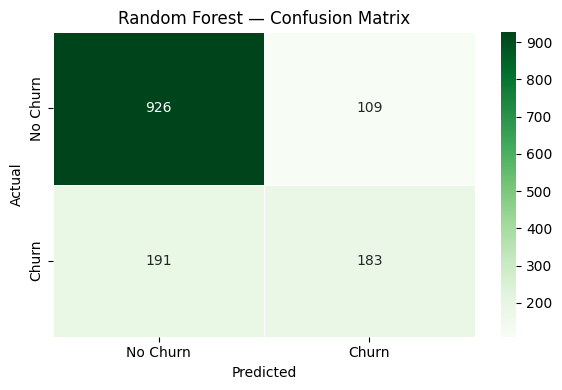

In [ ]:
plt.figure(figsize=(6, 4))

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            linewidths=0.5)

plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

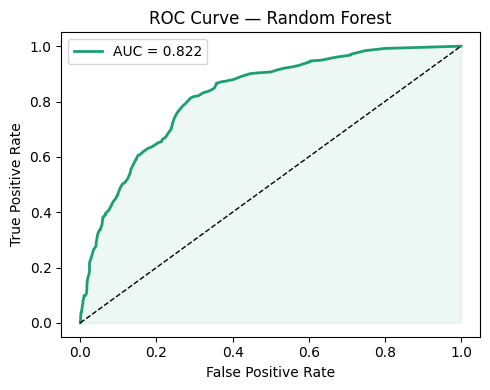

In [ ]:
# ROC Curve
plt.figure(figsize=(5, 4))
fpr, tpr, _ = roc_curve(y_test, rf_prob)
auc = roc_auc_score(y_test, rf_prob)
plt.plot(fpr, tpr, color='#1D9E75', lw=2, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.fill_between(fpr, tpr, alpha=0.08, color='#1D9E75')
plt.title('ROC Curve — Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# **XGBOOST**

In [ ]:
print("\n=====================")
print("    XGBOOST")
print("======================")
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, xgb_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, xgb_prob), 4))


    XGBOOST
Accuracy : 0.7857
ROC-AUC  : 0.8214


In [ ]:
print("XGBoost — Classification Report:\n")

print(classification_report(
    y_test, xgb_pred,
    target_names=['No Churn', 'Churn']
))

XGBoost — Classification Report:

              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1035
       Churn       0.61      0.54      0.57       374

    accuracy                           0.79      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.78      0.79      0.78      1409



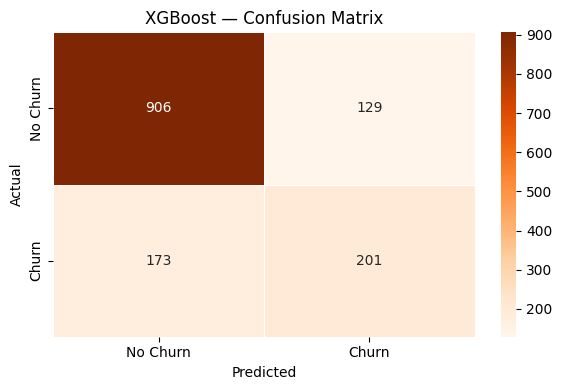

In [ ]:
plt.figure(figsize=(6, 4))

cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            linewidths=0.5)

plt.title('XGBoost — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

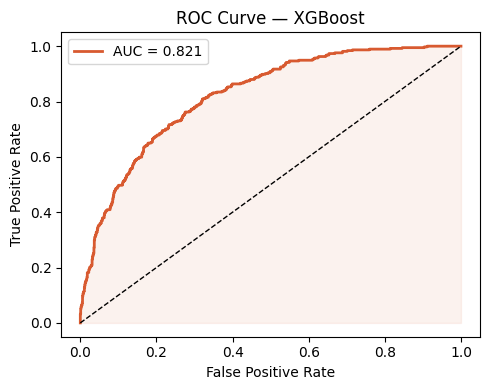

In [ ]:
# ROC Curve
plt.figure(figsize=(5, 4))
fpr, tpr, _ = roc_curve(y_test, xgb_prob)
auc = roc_auc_score(y_test, xgb_prob)
plt.plot(fpr, tpr, color='#D85A30', lw=2, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.fill_between(fpr, tpr, alpha=0.08, color='#D85A30')
plt.title('ROC Curve — XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# MODEL COMPARISON

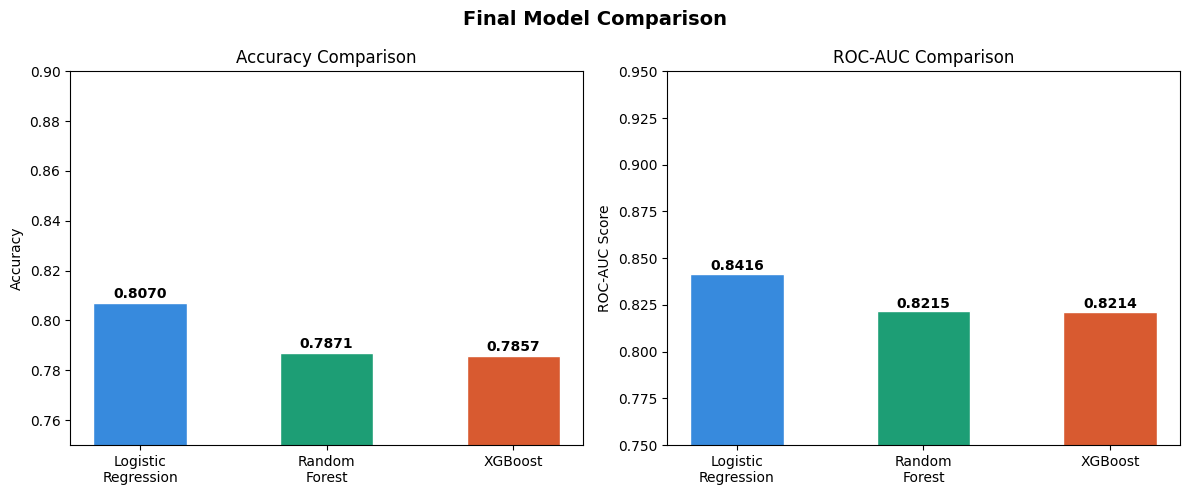

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Final Model Comparison', fontsize=14, fontweight='bold')

model_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
accuracies  = [accuracy_score(y_test, lr_pred),
               accuracy_score(y_test, rf_pred),
               accuracy_score(y_test, xgb_pred)]
aucs        = [roc_auc_score(y_test, lr_prob),
               roc_auc_score(y_test, rf_prob),
               roc_auc_score(y_test, xgb_prob)]
clrs        = ['#378ADD', '#1D9E75', '#D85A30']

bars = axes[0].bar(model_names, accuracies, color=clrs, edgecolor='white', width=0.5)
for bar, val in zip(bars, accuracies):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0.75, 0.90])

bars2 = axes[1].bar(model_names, aucs, color=clrs, edgecolor='white', width=0.5)
for bar, val in zip(bars2, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim([0.75, 0.95])

plt.tight_layout()
plt.show()

In [ ]:
summary = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy' : [round(a, 4) for a in accuracies],
    'ROC-AUC'  : [round(a, 4) for a in aucs]
})
print("\n===== FINAL MODEL SUMMARY =====")
print(summary.to_string(index=False))
print("================================")


===== FINAL MODEL SUMMARY =====
              Model  Accuracy  ROC-AUC
Logistic Regression    0.8070   0.8416
      Random Forest    0.7871   0.8215
            XGBoost    0.7857   0.8214
